# PAPER

In [ ]:
# Install library (Colab)
!pip install PyMuPDF networkx nltk matplotlib pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 39.3 MB/s eta 0:00:00


In [ ]:
# Import library
import fitz  # PyMuPDF
import re
import nltk
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

from collections import Counter
from itertools import combinations
from nltk.corpus import stopwords

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

LOAD & EKSTRAK TEKS DARI PDF

In [ ]:
def extract_text_from_pdf(pdf_path):
    doc = fitz.open(pdf_path)
    text = ""
    for page in doc:
        text += page.get_text()
    return text


In [ ]:
# Jalankan fungsi
pdf_path = "/content/pepertugas.pdf"
raw_text = extract_text_from_pdf(pdf_path)

print("Jumlah karakter:", len(raw_text))
print("\nContoh teks:\n")
print(raw_text[:1000])


Jumlah karakter: 37028

Contoh teks:

 
 
https://doi.org/10.56211/sudo.v3i4.668  
 
Attribution-ShareAlike 4.0 International Some rights reserved 
Pengolahan Citra Digital 
Implementasi Metode Gray Level Co-Occurrence Matrix Menganalisis Tekstur 
Kulit Wajah  
Rizky Fauzan Naibaho *, Indah Purnama Sari 
Fakultas Ilmu Komputer dan Teknologi Informasi, Teknologi Informasi, Universitas Muhammadiyah Sumatera Utara, Medan, Indonesia 
 
 
 
INFORMASI ARTIKEL 
 
A B S T R A K  
 
Diterima Redaksi: 08 Oktober 2024 
Revisi Akhir: 03 Juni 2025 
Diterbitkan Online: 11 Juni 2025 
 
GLCM merupakan metode analisis gambar yang dapat mengukur berbagai fitur 
tekstur seperti kontras, korelasi, energi, dan homogenitas dari gambar bergradasi 
abu-abu. Skripsi ini bertujuan untuk mengeksplorasi efektivitas GLCM dalam 
mengekstraksi dan menganalisis informasi tekstur dari kulit wajah, serta aplikasinya 
dalam bidang seperti deteksi penyakit kulit dan pengenalan wajah. dalam penelitian 
ini, gambar kulit w

PREPROCESSING TEKS

In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()

    stop_words = set(stopwords.words('indonesian'))
    tokens = [t for t in tokens if t not in stop_words and len(t) > 3]

    return tokens


In [ ]:
# Jalankan fungsi
tokens = preprocess_text(raw_text)

print("Jumlah token bersih:", len(tokens))
print("Contoh token:", tokens[:30])


Jumlah token bersih: 2771
Contoh token: ['https', 'sudo', 'attribution', 'sharealike', 'international', 'some', 'rights', 'reserved', 'pengolahan', 'citra', 'digital', 'implementasi', 'metode', 'gray', 'level', 'occurrence', 'matrix', 'menganalisis', 'tekstur', 'kulit', 'wajah', 'rizky', 'fauzan', 'naibaho', 'indah', 'purnama', 'sari', 'fakultas', 'ilmu', 'komputer']


MEMBANGUN WORD CO-OCCURRENCE GRAPH

In [ ]:
def build_word_graph_with_matrix(tokens, window_size=2, top_n=20):
    # Ambil kata paling sering
    vocab = Counter(tokens).most_common(top_n)
    words = [w for w, _ in vocab]

    # Inisialisasi matrix
    matrix = pd.DataFrame(0, index=words, columns=words)

    # Inisialisasi graph
    G = nx.Graph()

    # Bangun matrix & graph BERSAMA
    for i in range(len(tokens) - window_size):
        window = tokens[i:i + window_size]
        for w1, w2 in combinations(window, 2):
            if w1 in words and w2 in words:
                # Update matrix
                matrix.loc[w1, w2] += 1
                matrix.loc[w2, w1] += 1

                # Update graph (LOGIKA TIDAK DIUBAH)
                if G.has_edge(w1, w2):
                    G[w1][w2]['weight'] += 1
                else:
                    G.add_edge(w1, w2, weight=1)

    return matrix, G


In [ ]:
co_matrix, word_graph = build_word_graph_with_matrix(tokens)

print("Jumlah Node :", word_graph.number_of_nodes())
print("Jumlah Edge :", word_graph.number_of_edges())

co_matrix

Jumlah Node : 20
Jumlah Edge : 72


,citra,kulit,tekstur,wajah,sari,glcm,gambar,metode,aplikasi,sistem,penelitian,fitur,jurnal,teknik,analisis,sudo,data,proses,rizky,fauzan
citra,16,1,1,0,0,2,1,0,2,1,1,3,0,0,1,0,2,2,1,0
kulit,1,2,26,39,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
tekstur,1,26,0,0,0,0,4,1,0,0,1,7,0,0,5,0,0,0,0,0
wajah,0,39,0,0,0,1,1,0,1,0,2,0,0,0,1,0,0,2,1,0
sari,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,1,0,0,0,0
glcm,2,0,0,1,0,0,3,10,0,0,1,4,0,1,3,0,0,1,0,0
gambar,1,1,4,1,0,3,6,1,2,2,1,0,0,1,2,1,0,2,0,0
metode,0,0,1,0,0,10,1,0,0,0,0,0,0,1,4,0,0,0,0,0
aplikasi,2,0,0,1,1,0,2,0,0,4,2,1,0,0,1,0,0,2,0,0
sistem,1,0,0,0,0,0,2,0,4,0,0,0,0,0,0,0,0,0,1,0


VISUALISASI WORD GRAPH

In [ ]:
def visualize_word_graph(G, top_n=30):
    degrees = dict(G.degree())
    top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:top_n]
    subgraph = G.subgraph(top_nodes)

    plt.figure(figsize=(14, 14))
    pos = nx.spring_layout(subgraph, k=0.4)

    nx.draw_networkx_nodes(subgraph, pos, node_size=800)
    nx.draw_networkx_edges(subgraph, pos, alpha=0.5)
    nx.draw_networkx_labels(subgraph, pos, font_size=10)

    plt.title("Word Graph dari Paper (Top Kata)")
    plt.axis('off')
    plt.show()


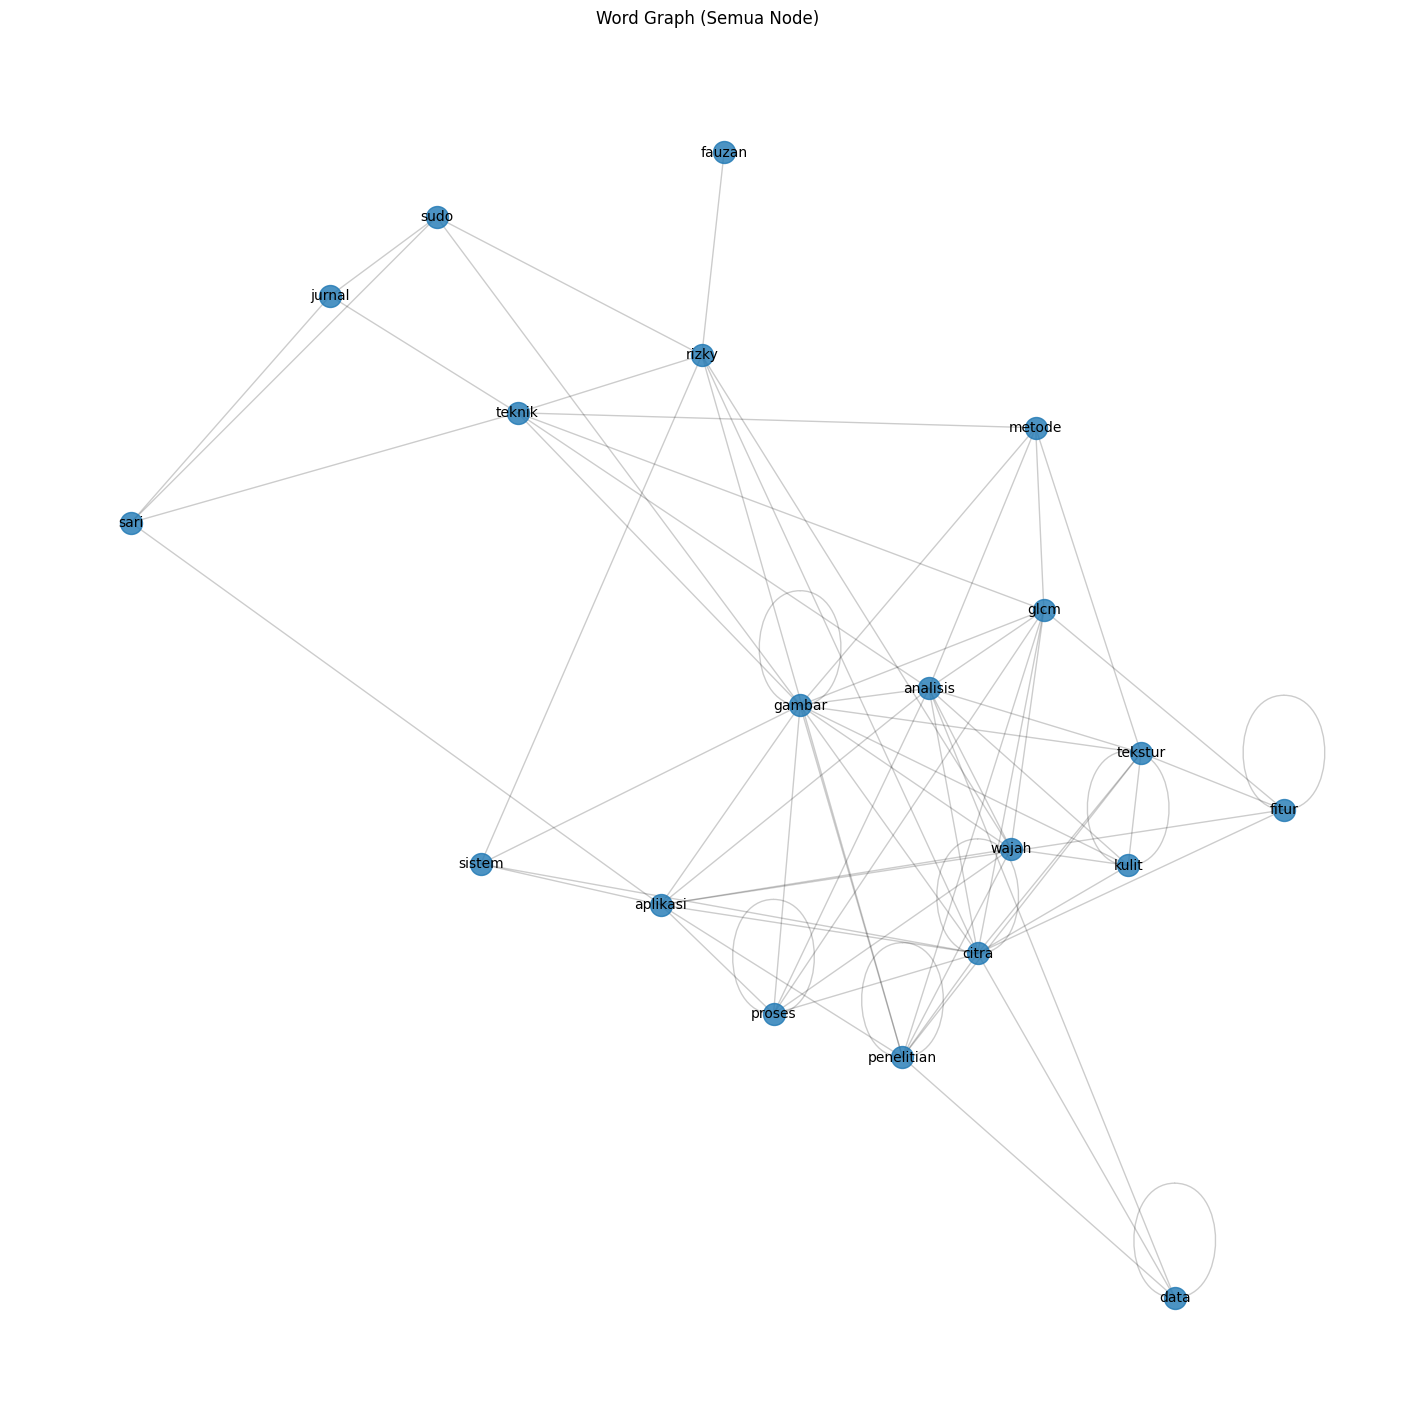

In [ ]:
# Tampilkan graph
visualize_word_graph(word_graph)


HITUNG PAGE RANK CENTRALITY

In [ ]:
def compute_pagerank(G):
    pr = nx.pagerank(G, weight='weight')
    df = pd.DataFrame(pr.items(), columns=['Kata', 'PageRank'])
    df = df.sort_values(by='PageRank', ascending=False)
    return df


In [ ]:
# Jalankan PageRank
pagerank_df = compute_pagerank(word_graph)

pagerank_df.head(15)


,Kata,PageRank
9,citra,0.019128
19,kulit,0.015521
26,sari,0.012515
18,tekstur,0.011718
20,wajah,0.011162
46,glcm,0.010474
48,gambar,0.009878
12,metode,0.009532
88,aplikasi,0.008931
184,sistem,0.008846


In [ ]:
top_keywords = pagerank_df.head(10)

top_keywords


,Kata,PageRank
9,citra,0.019128
19,kulit,0.015521
26,sari,0.012515
18,tekstur,0.011718
20,wajah,0.011162
46,glcm,0.010474
48,gambar,0.009878
12,metode,0.009532
88,aplikasi,0.008931
184,sistem,0.008846
